# Using AI to gain a better understandig of BBD-PS-InSAR Time Series

## Problem

In [4]:
!git branch --show-current

non_bbd


In [5]:
from IPython.core.display import HTML 
from yahoo_kursdaten import yahoo_kursdaten

# Data preparation

## Imports and Drive-Connection

In [6]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np

import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timedelta
from numpy import datetime64
import re
import tensorflow as tf
print(tf.__version__)
tf.get_logger().setLevel('ERROR')


I0000 00:00:1790857978.877166  294392 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790857980.364916  294392 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


2.21.0


## Hyperparameters

In [8]:
window_size = 10
batch_size = 32
shuffle_buffer = 1000

## Data

Some data is missing due to orbitting reasons. Do interpolation.

In [9]:

df=pd.read_csv('52028209n.csv')


df.head()

df.iloc[0]

date_20150401    0.000000
date_20150413   -7.013970
date_20150425   -4.924180
date_20150507   -4.619620
date_20150531   -3.693010
                   ...   
date_20211125   -5.804410
date_20211201   -0.312103
date_20211207   -6.326710
date_20211213   -0.969059
date_20211219   -0.227574
Name: 0, Length: 348, dtype: float64

## Adding missing days

In [10]:
# Get acquisition dates from column names
day_flag = 'date_'
regxx = day_flag

dats   = []
nodats = []
for c in df.columns:
    if re.findall(regxx,c):
        dats.append(c)
    else:
        nodats.append(c)
        
dt_dats = [datetime64(c[5:9]+'-'+c[9:11]+'-'+c[11:13]) for c in dats]


In [11]:
# fill in missing dates

dt_dats_padded = [dt_dats[0]]

old_date = dt_dats[0]
while old_date<dt_dats[-1]:
    old_date += 6
    dt_dats_padded.append(old_date)

#print(dt_dats_padded)

dt_dats_asDays = (dt_dats-dt_dats[0]).astype('float')
dt_dats_asDays_padded = (dt_dats_padded-dt_dats_padded[0]).astype('float')

print(type(dt_dats_asDays_padded),type(dt_dats_asDays))
print(len(dt_dats_padded), len(dt_dats_asDays_padded))


<class 'numpy.ndarray'> <class 'numpy.ndarray'>
410 410


/tmp/ipykernel_294392/2079547032.py:7: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  old_date += 6


In [12]:
# Interpolate values


this_ps = df.iloc[0]
this_ts = this_ps[dats]
this_mv = this_ps[nodats]
# padding missing values in a six-day rhythm
# with linearly interpolated data

# allocating new lists
#this_ts_padded = [this_ts.iloc[0]]

# fill in missing values
this_ts_padded = np.interp(dt_dats_asDays_padded, dt_dats_asDays, this_ts.astype('float'))
#print(np.max(this_ts_padded), np.min(this_ts_padded))
n_max = np.max(this_ts_padded)
n_min = np.min(this_ts_padded)

this_ps_padded = [*this_mv, *this_ts_padded]
this_ps_padded = np.asarray(this_ps_padded).T



   

## Plot Observed Data

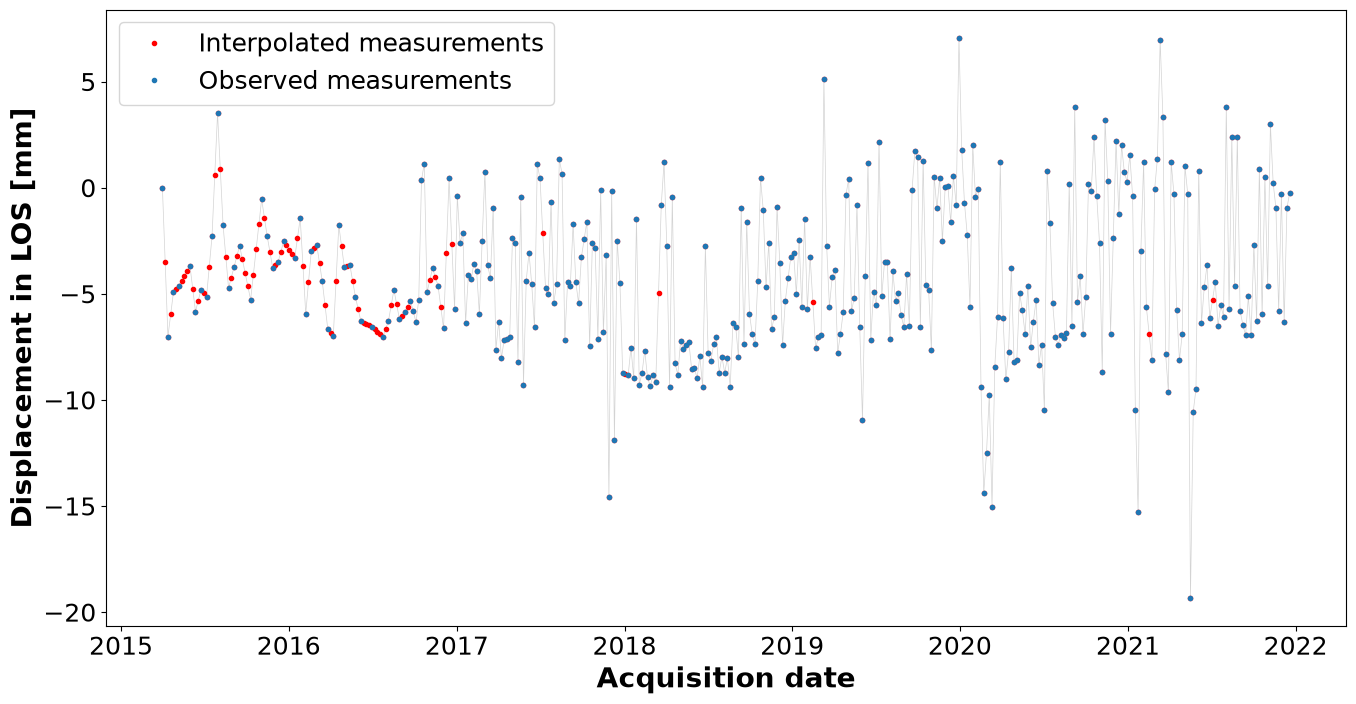

In [13]:
plt.rcParams['figure.facecolor'] = 'white'
plt.figure(figsize=[16,8])
plt.plot(dt_dats_padded, this_ps_padded,color='lightgray', linewidth=0.5)
plt.plot(dt_dats_padded, this_ps_padded,'r.', label='Interpolated measurements')
plt.plot(dt_dats, this_ps.values,'.', label='Observed measurements')
plt.ylabel('Displacement in LOS [mm]', fontsize = 20, fontweight='bold')
plt.xlabel('Acquisition date', fontsize=20, fontweight='bold')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)

## Detrending - take care of "%%script"-option

In [14]:
%%script echo skipping
series2 = np.copy(series) # make a copy!

myfit = np.polyfit(time, series,1)
mytrend = np.polyval(myfit, time)

series_trendfree = [i-j for i,j in zip(series,mytrend)]
series_trendfree = np.asarray(series_trendfree)
print(np.min(series_trendfree))


plt.figure(figsize=[16,9])
plt.plot(time, series)
plt.plot(time, series_trendfree, 'r', linewidth=3)

skipping


In [15]:
# Decide, what data to use: series or the trendfree one
# THIS IS THE POINT TO START OVER WHEN SOMETHING WENT WRONG

time = dt_dats_asDays_padded
this_signal = this_ps_padded #or
#signal = series_trendfree
print(type(this_signal), len(this_signal))
#print(this_signal)


<class 'numpy.ndarray'> 410


### The new cell: generating sample data

In [18]:
%%script echo skipping
SEED = 42
n_example = 410
dates = pd.date_range("2017-01-01", periods=n_example, freq="6D")
elapsed_days = (dates - dates[0]).days.to_numpy()
rng = np.random.default_rng(SEED)
displacement = (
    -2.2 * elapsed_days / 365.25
    + 3.0 * np.sin(2 * np.pi * elapsed_days / 365.25 + 0.3)
    - 1.0 * np.maximum(elapsed_days - 1650, 0) / 365.25
    + rng.normal(0, 0.65, n_example)
)
df = pd.DataFrame({"ground_motion_mm": displacement}, index=dates)
df.index.name = "date"
df.head()

this_signal = df.to_numpy().ravel()
print(type(this_signal), len(this_signal))
#print(this_signal)


skipping


### Alternative: stock data

In [24]:
ndf = yahoo_kursdaten('DE000HAG0005', "07/02/2025-20/09/2026")
print(len(ndf))
ndf.tail()

410


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2026-09-14 00:00:00+02:00,76.459999,78.260002,75.980003,76.860001,76.860001,215111
2026-09-15 00:00:00+02:00,76.099998,78.300003,75.779999,77.099998,77.099998,304672
2026-09-16 00:00:00+02:00,77.919998,79.180000,76.620003,77.779999,77.779999,161317
2026-09-17 00:00:00+02:00,78.800003,79.839996,76.900002,77.680000,77.680000,146635
2026-09-18 00:00:00+02:00,78.000000,79.980003,77.680000,78.120003,78.120003,335262


In [25]:
this_signal = ndf['Close'].to_numpy().ravel()
print(type(this_signal), len(this_signal))


<class 'numpy.ndarray'> 410


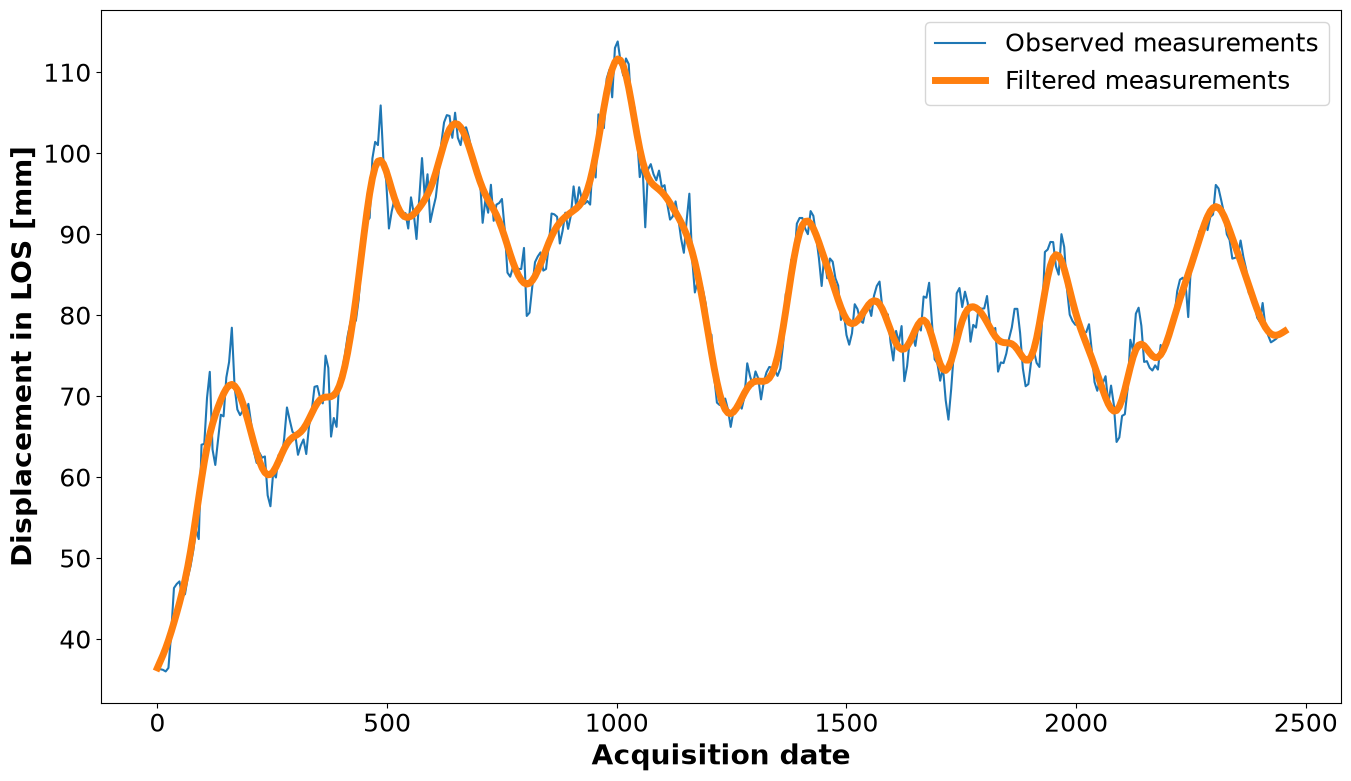

In [26]:
from scipy import signal

omega_g = 1./90      #cut off frequency
fs      = 1./6     

this_omega_g = omega_g
sos = signal.butter(3, this_omega_g, 'lp', fs=fs, output='sos')
this_signal_filtered = signal.sosfiltfilt(sos, this_signal)

plt.figure(figsize=[16,9])
plt.plot(time, this_signal, label='Observed measurements')
plt.plot(time, this_signal_filtered, linewidth=5, label='Filtered measurements')

this_signal = this_signal_filtered
plt.ylabel('Displacement in LOS [mm]', fontsize = 20, fontweight='bold')
plt.xlabel('Acquisition date', fontsize=20, fontweight='bold')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)


In [27]:
def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
    """Generates dataset windows

    Args:
      series (array of float) - contains the values of the time series
      window_size (int) - the number of time steps to include in the feature
      batch_size (int) - the batch size
      shuffle_buffer(int) - buffer size to use for the shuffle method

    Returns:
      dataset (TF Dataset) - TF Dataset containing time windows
    """
  
    # Generate a TF Dataset from the series values
    dataset = tf.data.Dataset.from_tensor_slices(series)
    
    # Window the data but only take those with the specified size
    dataset = dataset.window(window_size + 1, shift=1, drop_remainder=True)
    
    # Flatten the windows by putting its elements in a single batch
    dataset = dataset.flat_map(lambda window: window.batch(window_size + 1))

    # Create tuples with features and labels 
    dataset = dataset.map(lambda window: (window[:-1], window[-1]))

    # Shuffle the windows
    dataset = dataset.shuffle(shuffle_buffer)
    
    # Create batches of windows
    dataset = dataset.batch(batch_size).prefetch(1)
    
    return dataset

## **Split dataset**

In [28]:
# Define the split time
split_time = 340



# Get the train set 
time_train = time[:split_time]
x_train = this_signal[:split_time]

# Get the validation set
time_valid = time[split_time:]
x_valid = this_signal[split_time:]

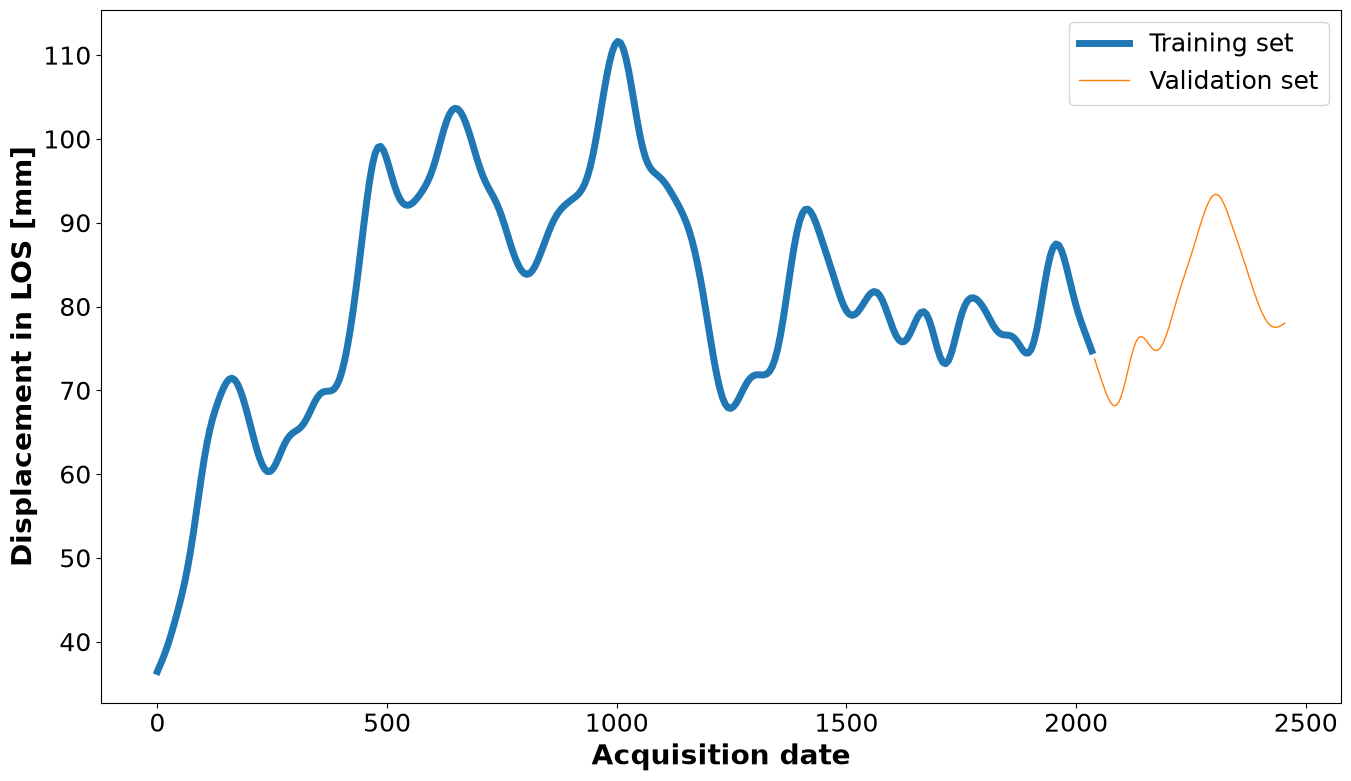

In [29]:
# Plot the train set
plt.figure(figsize=[16,9])
plt.plot(time_train, x_train, linewidth=5, label='Training set')
plt.plot(time_valid, x_valid, linewidth=1, label='Validation set')
plt.ylabel('Displacement in LOS [mm]', fontsize = 20, fontweight='bold')
plt.xlabel('Acquisition date', fontsize=20, fontweight='bold')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)

In [30]:
train_set = windowed_dataset(x_train, window_size, batch_size, shuffle_buffer)

# The AI-part

## The model [2]

There's another model at the end of this notebook: the "Sunspot model" from Coursera's Tensorflow Time Series Course (where this is taken from, too).

In [44]:
# Build the architecture once as a factory for independent models.
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

def build_model():
    return tf.keras.models.Sequential([
        tf.keras.Input(shape=(window_size, 1)),
        tf.keras.layers.Conv1D(
            filters=64, kernel_size=3, strides=1,
            padding="causal", activation="relu",
        ),
        tf.keras.layers.LSTM(64, return_sequences=True),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(1),
        tf.keras.layers.Lambda(lambda x: x * 20.),
    ])

model = build_model()
# Both the LR test and actual training start from these untrained weights.
initial_weights = [weight.copy() for weight in model.get_weights()]


In [45]:
#model = tf.keras.models.load_model('./model/experiment001/')

In [46]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 10, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 10, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,369 (259.25 KB)

 Trainable params: 66,369 (259.25 KB)

 Non-trainable params: 0 (0.00 B)

### 2.1 Lernraten-Test mit Adam und MSE

Die nächsten beiden Zellen testen dieselbe Architektur, denselben Adam-Optimierer
und denselben MSE-Loss wie das eigentliche Training. Zuerst die Modellaufbau-Zelle
ausführen: Sie speichert einen reproduzierbaren, untrainierten Ausgangszustand.

Der Suchlauf trainiert ausschließlich `lr_model` auf den Trainingsdaten. Das
vorhandene `model` bleibt unverändert. Die Gewichte und der Adam-Zustand des
Suchlaufs werden anschließend nicht für das eigentliche Training übernommen.

Die Lernrate steigt innerhalb eines zusammenhängenden Trainingslaufs von `1e-6`
bis `1e-2`. Jeder Kurvenpunkt ist der durchschnittliche Trainings-MSE einer Epoche;
die Punkte sind keine unabhängigen Trainingsversuche. Der Kurvenverlauf liefert
einen Kandidatenbereich, keine garantiert optimale Lernrate. Eine gewählte Rate
sollte zusätzlich anhand zeitlich nachgelagerter Validierungsdaten geprüft werden.


In [47]:
# Learning-rate range test: independent model, fresh Adam, same MSE loss.
LR_MIN = 1e-6
LR_MAX = 1e-2
LR_EPOCHS = 100
if not 0 < LR_MIN < LR_MAX or LR_EPOCHS < 2:
    raise ValueError("Require 0 < LR_MIN < LR_MAX and at least two epochs.")

lr_values = np.geomspace(LR_MIN, LR_MAX, LR_EPOCHS)
lr_train_set = train_set.map(
    lambda x, y: (
        tf.cast(x[..., tf.newaxis], tf.float32),
        tf.cast(y[..., tf.newaxis], tf.float32),
    )
)
lr_model = build_model()
lr_model.set_weights(initial_weights)
lr_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_MIN),
    loss="mse",
)
lr_schedule = tf.keras.callbacks.LearningRateScheduler(
    lambda epoch, current_lr: float(lr_values[epoch])
)

lr_history = lr_model.fit(
    lr_train_set,
    epochs=LR_EPOCHS,
    callbacks=[lr_schedule, tf.keras.callbacks.TerminateOnNaN()],
    shuffle=False,  # train_set already shuffles its windows
    verbose=2,
)
# Account for an early stop on a non-finite loss.
lrs = lr_values[:len(lr_history.history["loss"])]


Epoch 1/100
11/11 - 3s - 271ms/step - loss: 6652.8706 - learning_rate: 1.0000e-06
Epoch 2/100
11/11 - 0s - 12ms/step - loss: 6639.3999 - learning_rate: 1.0975e-06
Epoch 3/100
11/11 - 0s - 11ms/step - loss: 6624.3843 - learning_rate: 1.2045e-06
Epoch 4/100
11/11 - 0s - 12ms/step - loss: 6607.7612 - learning_rate: 1.3219e-06
Epoch 5/100
11/11 - 0s - 11ms/step - loss: 6589.3101 - learning_rate: 1.4508e-06
Epoch 6/100
11/11 - 0s - 12ms/step - loss: 6569.1665 - learning_rate: 1.5923e-06
Epoch 7/100
11/11 - 0s - 12ms/step - loss: 6546.9453 - learning_rate: 1.7475e-06
Epoch 8/100
11/11 - 0s - 11ms/step - loss: 6522.4092 - learning_rate: 1.9179e-06
Epoch 9/100
11/11 - 0s - 11ms/step - loss: 6495.7031 - learning_rate: 2.1049e-06
Epoch 10/100
11/11 - 0s - 11ms/step - loss: 6466.0649 - learning_rate: 2.3101e-06
Epoch 11/100
11/11 - 0s - 11ms/step - loss: 6433.2559 - learning_rate: 2.5354e-06
Epoch 12/100
11/11 - 0s - 11ms/step - loss: 6396.8354 - learning_rate: 2.7826e-06
Epoch 13/100
11/11 - 0s 

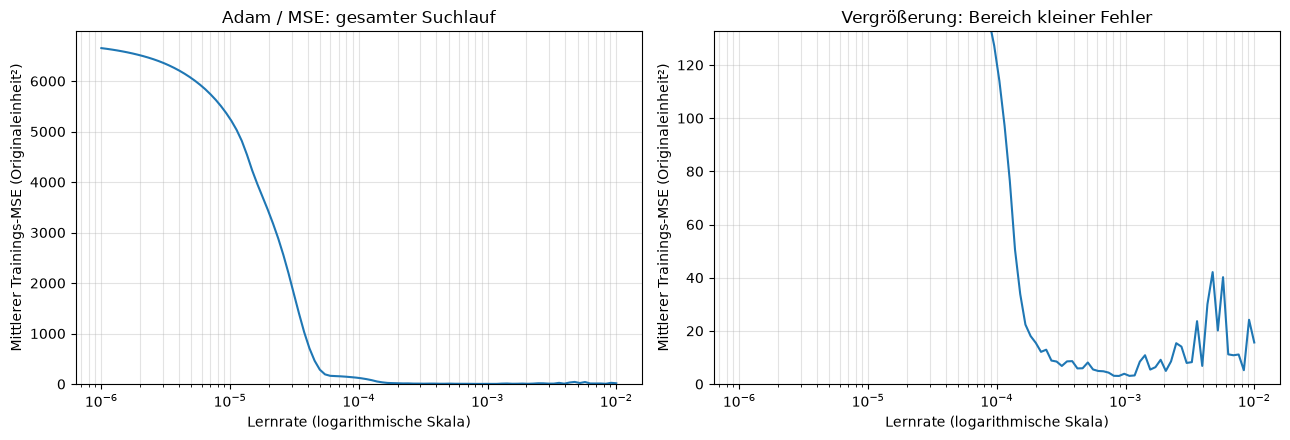

Kleinster protokollierter Trainings-MSE: 3.04852
Lernrate an diesem Punkt: 0.00089
Dies ist keine automatisch validierte optimale Lernrate.
Die Rate für das eigentliche Training wird in der nächsten Codezelle gesetzt.


In [48]:
# X: logarithmic learning rate; Y: linear mean training MSE.
lr_losses = np.asarray(lr_history.history["loss"], dtype=float)
finite = np.isfinite(lr_losses)
if not finite.any():
    raise ValueError("No finite losses recorded; check the data and LR_MIN.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax in axes:
    ax.semilogx(lrs, lr_losses)
    ax.set_xlabel("Lernrate (logarithmische Skala)")
    ax.set_ylabel("Mittlerer Trainings-MSE (Originaleinheit²)")
    ax.grid(True, which="both", alpha=0.35)
axes[0].set_title("Adam / MSE: gesamter Suchlauf")
axes[0].set_ylim(bottom=0)

# Zoom into the lower-loss region without a fixed, data-dependent scale of 0–50.
zoom_upper = max(float(np.median(lr_losses[finite])) * 1.1, np.finfo(float).eps)
axes[1].set_ylim(0, zoom_upper)
axes[1].set_title("Vergrößerung: Bereich kleiner Fehler")
plt.tight_layout()
plt.show()

best_index = np.flatnonzero(finite)[np.argmin(lr_losses[finite])]
print(f"Kleinster protokollierter Trainings-MSE: {lr_losses[best_index]:.6g}")
print(f"Lernrate an diesem Punkt: {lrs[best_index]:.3g}")
print("Dies ist keine automatisch validierte optimale Lernrate.")
print("Die Rate für das eigentliche Training wird in der nächsten Codezelle gesetzt.")


# Train the model

`learning_rate` unten ist die Rate für das eigentliche Training. Der bisherige
Wert `1e-3` bleibt als Ausgangswert stehen; der Suchlauf überschreibt ihn nicht.
Nach Betrachtung der Kurve kann hier ein Kandidat aus einem stabilen Bereich
eingetragen werden.

Diese Zelle setzt die Modellgewichte auf den gespeicherten untrainierten
Ausgangszustand zurück und verwendet einen neuen Adam-Optimierer. Ein erneuter
Aufruf startet daher ein neues Training. `history` enthält dessen Verlauf;
`lr_history` bleibt ausschließlich dem Lernraten-Test zugeordnet.


In [49]:
# Set the candidate learning rate after inspecting the separate LR test.
learning_rate = 8.9e-4

# Match the model's expected shapes:
# inputs: [batch, window_size, 1], targets: [batch, 1]
train_set_3d = train_set.map(
    lambda x, y: (
        tf.cast(x[..., tf.newaxis], tf.float32),
        tf.cast(y[..., tf.newaxis], tf.float32),
    )
)

# Restart with untrained weights and a fresh optimizer, never the sweep state.
model.set_weights(initial_weights)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss="mse",
)

history = model.fit(
    train_set_3d,
    epochs=400,
    shuffle=False,  # train_set already shuffles its windows
    verbose=2,
)


Epoch 1/400
11/11 - 3s - 267ms/step - loss: 3052.7554
Epoch 2/400
11/11 - 0s - 12ms/step - loss: 287.2552
Epoch 3/400
11/11 - 0s - 12ms/step - loss: 171.2345
Epoch 4/400
11/11 - 0s - 11ms/step - loss: 159.6064
Epoch 5/400
11/11 - 0s - 11ms/step - loss: 145.9769
Epoch 6/400
11/11 - 0s - 11ms/step - loss: 121.6255
Epoch 7/400
11/11 - 0s - 12ms/step - loss: 99.9542
Epoch 8/400
11/11 - 0s - 11ms/step - loss: 59.7127
Epoch 9/400
11/11 - 0s - 11ms/step - loss: 31.0956
Epoch 10/400
11/11 - 0s - 11ms/step - loss: 27.0932
Epoch 11/400
11/11 - 0s - 11ms/step - loss: 23.4306
Epoch 12/400
11/11 - 0s - 12ms/step - loss: 18.9963
Epoch 13/400
11/11 - 0s - 12ms/step - loss: 18.3996
Epoch 14/400
11/11 - 0s - 11ms/step - loss: 23.2645
Epoch 15/400
11/11 - 0s - 11ms/step - loss: 14.2038
Epoch 16/400
11/11 - 0s - 11ms/step - loss: 7.5597
Epoch 17/400
11/11 - 0s - 11ms/step - loss: 6.3284
Epoch 18/400
11/11 - 0s - 11ms/step - loss: 5.0458
Epoch 19/400
11/11 - 0s - 11ms/step - loss: 3.9945
Epoch 20/400
11/1

## Now, let's make some predictions

In [50]:

# Initialize a list
forecast = []

# Reduce the original series
forecast_series = this_signal[split_time - window_size:]

# Use the model to predict data points per window size
for time1 in range(len(forecast_series) - window_size):
  forecast.append(model.predict(forecast_series[time1:time1 + window_size][np.newaxis]))

# Convert to a numpy array and drop single dimensional axes
results = np.array(forecast).squeeze()



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━

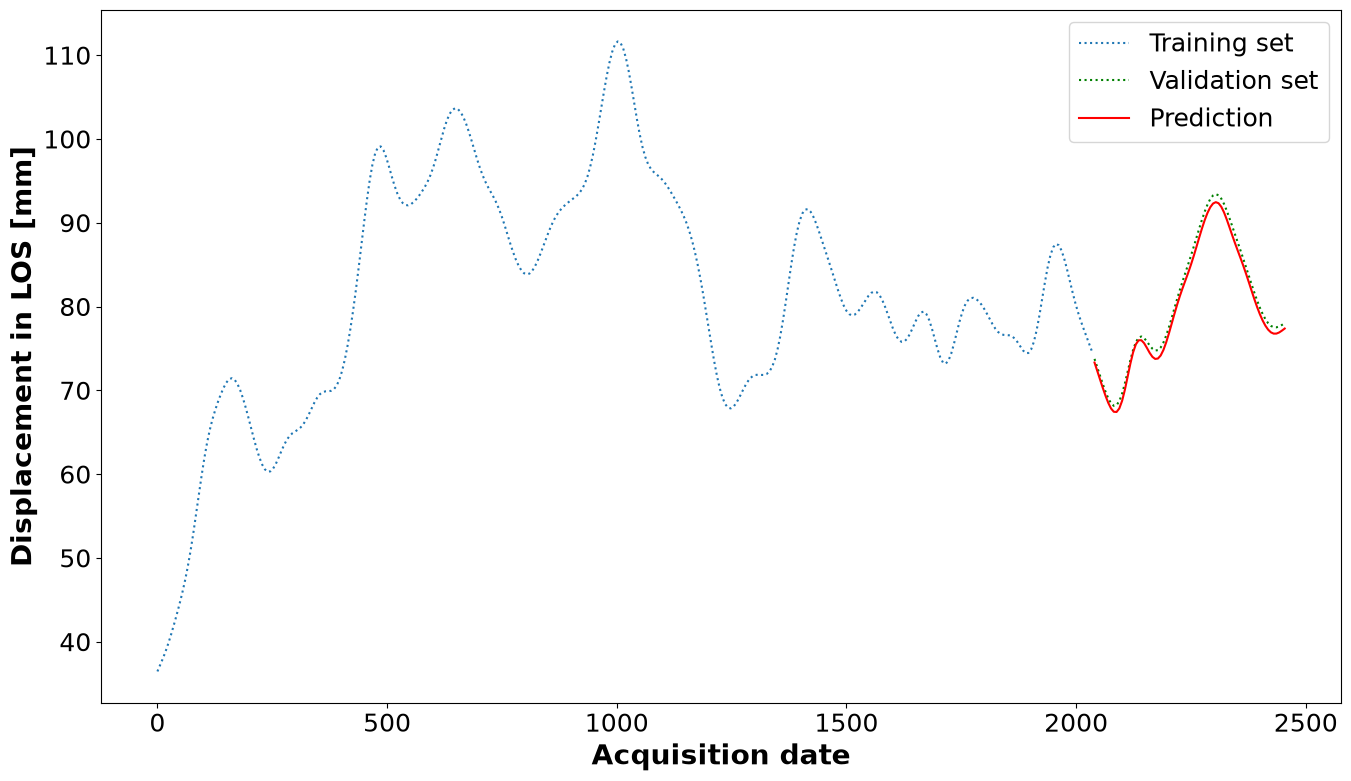

In [51]:
# Plot the train set
plt.figure(figsize=[16,9])
plt.plot(time_train, x_train, ':', label='Training set')
plt.plot(time_valid, x_valid, ':', color='green', label='Validation set')
plt.plot(time_valid, results,'-',color='red', label='Prediction')
plt.ylabel('Displacement in LOS [mm]', fontsize = 20, fontweight='bold')
plt.xlabel('Acquisition date', fontsize=20, fontweight='bold')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)
plt.savefig('pred.png')

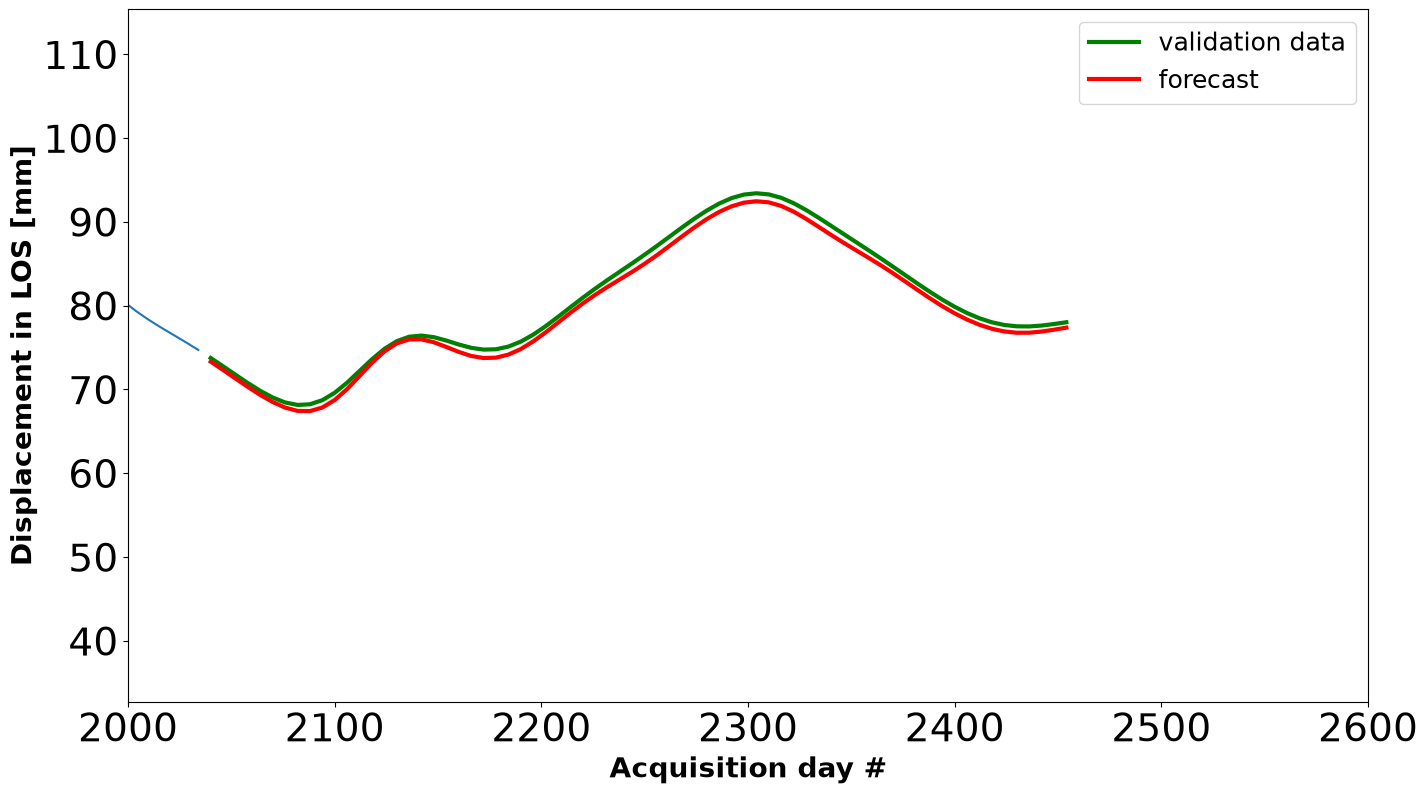

In [52]:
# Plot the train set
plt.figure(figsize=[16,9])
plt.plot(time_train, x_train)
plt.plot(time_valid, x_valid, color='green', linewidth=3, label= 'validation data')
plt.plot(time_valid, results, color='red', linewidth=3, label='forecast')
plt.legend()
plt.xlim([2000,2600])
plt.ylabel('Displacement in LOS [mm]', fontsize = 20, fontweight='bold')
plt.xlabel('Acquisition day #', fontsize=20, fontweight='bold')
plt.xticks(fontsize=28)
plt.yticks(fontsize=28)
plt.legend(fontsize=18)

In [53]:
# Compute the metrics

print("MSE:", tf.keras.metrics.MeanSquaredError()(x_valid, results).numpy())
print("MAE:", tf.keras.metrics.MeanAbsoluteError()(x_valid, results).numpy())

MSE: 0.67333263
MAE: 0.79277515


# Own Predictions

What happens, if we use our predictions as input for further predictions

In [54]:
# Initialize a list
native_forecast = []


# Reduce the original series
native_forecast_window = this_signal[split_time - window_size:split_time]

print(len(native_forecast_window))
# Use the model to predict data points per window size
for time1 in range(len(x_valid)):
  nft = model.predict(native_forecast_window[0:][np.newaxis])
  native_forecast.append(nft)
  native_forecast_window=np.append(native_forecast_window[1:],nft)


# Convert to a numpy array and drop single dimensional axes
native_results = np.array(native_forecast).squeeze()

10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━

In [55]:
# Calculate MSE

mse = []

for i,j in zip(native_results, x_valid):
  mse.append((i-j)**2)

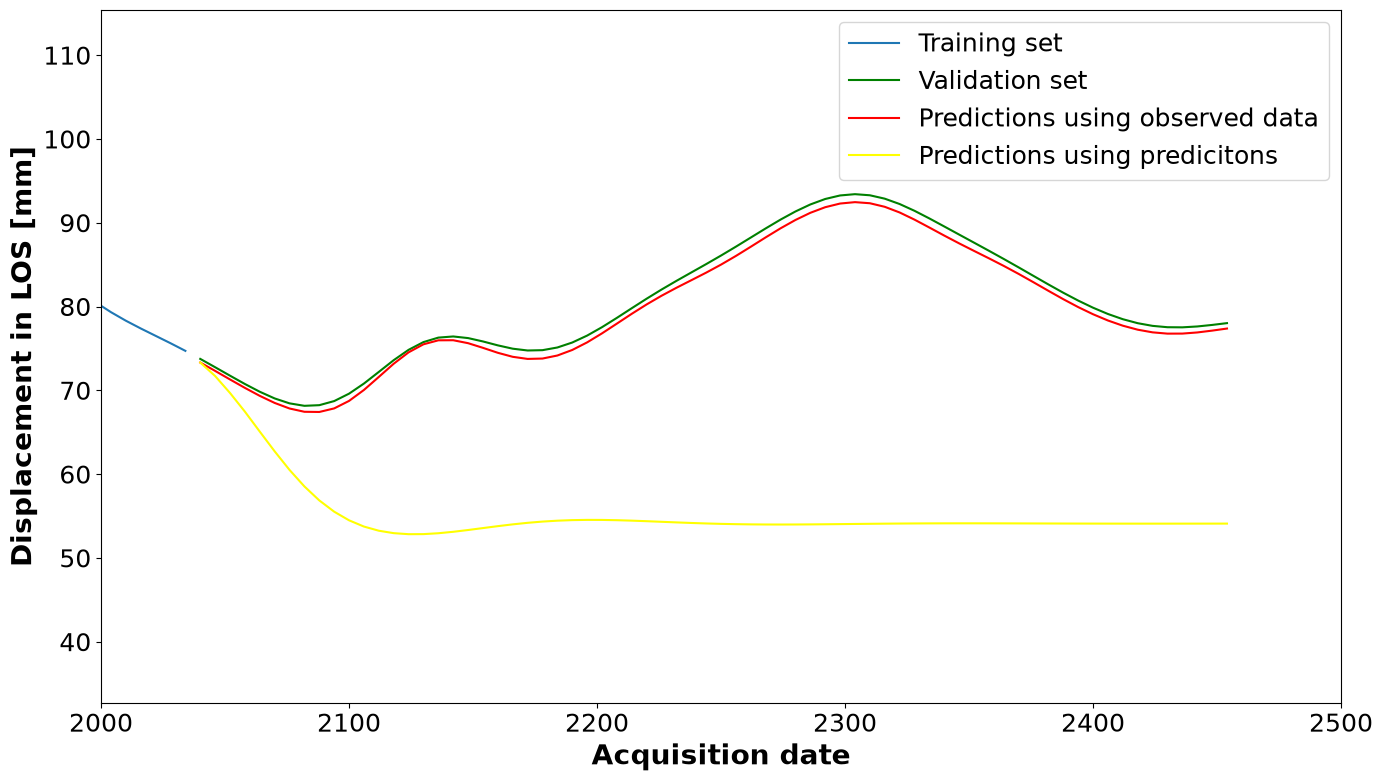

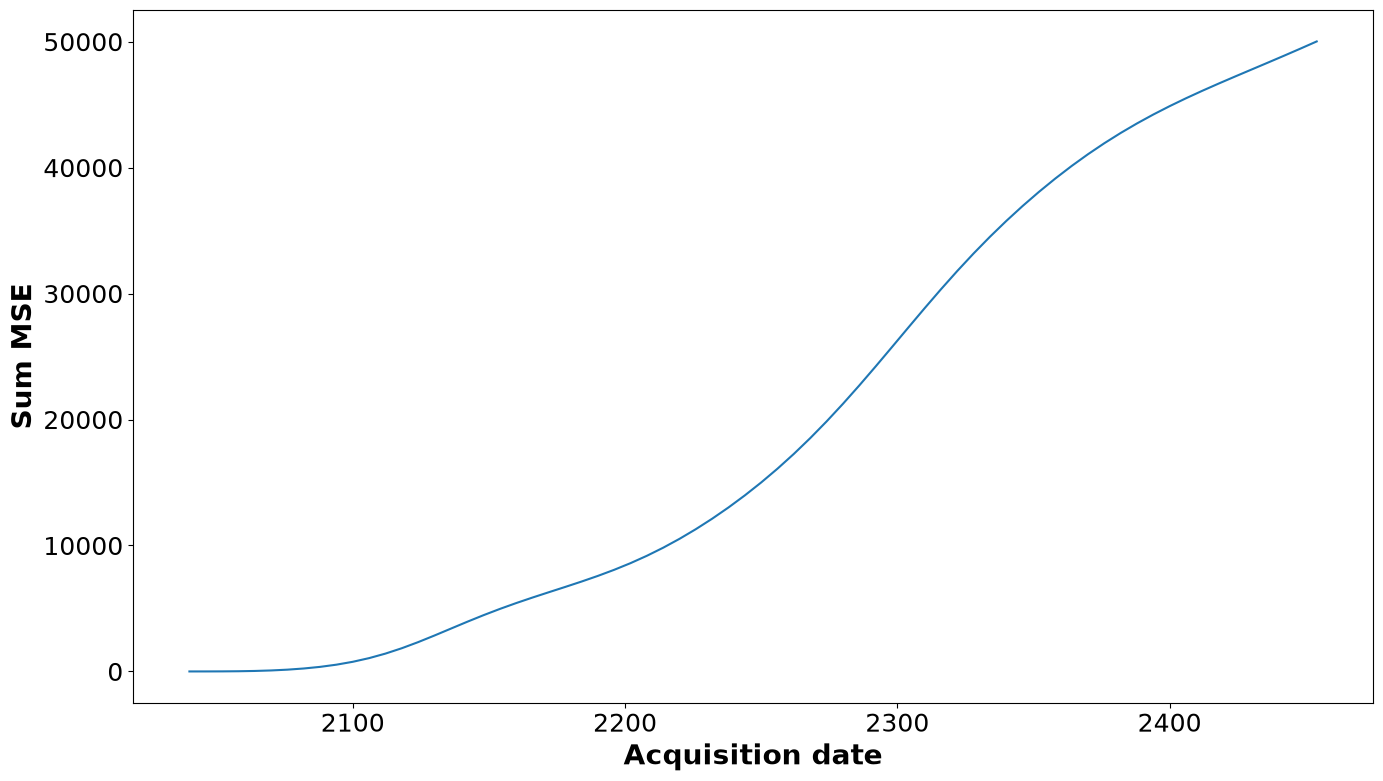

In [56]:

# Plot the train set
plt.figure(figsize=[16,9])
plt.plot(time_train, x_train, label='Training set')
plt.plot(time_valid, x_valid, color='green', label= 'Validation set')
plt.plot(time_valid, results, color='red', label='Predictions using observed data')
plt.plot(time_valid, native_results, color='yellow', label='Predictions using predicitons')
plt.ylabel('Displacement in LOS [mm]', fontsize = 20, fontweight='bold')
plt.xlabel('Acquisition date', fontsize=20, fontweight='bold')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)
plt.xlim([2000,2500])

plt.figure(figsize=[16,9])
plt.plot(time_valid, np.cumsum(mse))
plt.ylabel('Sum MSE', fontsize = 20, fontweight='bold')
plt.xlabel('Acquisition date', fontsize=20, fontweight='bold')
plt.xticks(fontsize=18);
plt.yticks(fontsize=18);


Oben: Das sieht aus, als ob sich auch auf Basis nativer Vorhersagen wenigstens 30 Werte gut vorhersagen lassen. Das wären immerhin 180 Tage. Wir filtern bei 90 Tagen. Das ist das Mindestmaß, das wir berücksichtigen können müssen, entsprechend sind das 15 Werte. Danach müsste das Modell nachgesteuert werden.


In [ ]:
print(tf.keras.metrics.mean_squared_error(x_valid, native_results).numpy())
print(tf.keras.metrics.mean_absolute_error(x_valid, native_results).numpy())

## A more realistic case: what happens, if something happens?

In [ ]:
# make a deep copy of the validation data
x_valid_alt = np.copy(x_valid)

# change the data from the 10th value on
for i in range(11,len(x_valid_alt)):
  x_valid_alt[i] = x_valid_alt[i]-5

plt.figure(figsize=[16,8])
plt.plot(time_valid,x_valid, color='green', label='Validation set')
plt.plot(time_valid,x_valid_alt, color='blue', label='Altered validation set')
#plt.plot(time_valid, native_results, color='orange', label='native forecast')
plt.plot(time_valid, results, color='red', label='Predictions using observed data')

plt.ylabel('Displacement in LOS [mm]', fontsize = 20, fontweight='bold')
plt.xlabel('Acquisition date', fontsize=20, fontweight='bold')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)

## A new forecast

In [ ]:
forecast_2 = []

# Reduce the original series
forecast_series_2 = this_signal[split_time - window_size:split_time]
forecast_series_2 = np.append(forecast_series_2, x_valid_alt.copy())

# Use the model to predict data points per window size
for time1 in range(len(forecast_series_2) - window_size):
  forecast_2.append(model.predict(forecast_series_2[time1:time1 + window_size][np.newaxis]))

# Convert to a numpy array and drop single dimensional axes
results_2 = np.array(forecast_2).squeeze()

In [ ]:
plt.figure(figsize=[16,8])
plt.plot(time_valid,x_valid, color='green',linewidth=3,  label='Validation set')
plt.plot(time_valid,x_valid_alt, color='blue',linewidth=3,  label='Altered validation set')
#plt.plot(time_valid, native_results, color='orange', label='native forecast')
plt.plot(time_valid, results, color='red', linewidth=3, label='Predictions using validation set')
plt.plot(time_valid, results_2, color='orange',linewidth=3,  label='Predicitons using altered validation set')
plt.ylabel('Displacement in LOS [mm]', fontsize = 20, fontweight='bold')
plt.xlabel('Acquisition day #', fontsize=20, fontweight='bold')
plt.xticks(fontsize=28)
plt.yticks(fontsize=28)
plt.legend(fontsize=18)

In [ ]:
mse_3 = []

for i,j in zip(x_valid_alt, results_2):
  mse_3.append((i-j)**2)
#print(mse_3)

plt.figure(figsize=[16,8])
plt.plot(time_valid,mse_3, 'o', label='MSE')
plt.ylabel('MSE', fontsize = 20, fontweight='bold')
plt.xlabel('Acquisition date', fontsize=20, fontweight='bold')
plt.xticks(fontsize=18);
plt.yticks(fontsize=18);


# Additional stuff 

## The Sunspot model

Source: https://colab.research.google.com/github/https-deeplearning-ai/tensorflow-1-public/blob/main/C4/W4/ungraded_labs/C4_W4_Lab_3_Sunspots_CNN_RNN_DNN.ipynb#scrollTo=y6kJd40-0Hj9

At the end of that notebook there's more to learn about changing the learning rate while training the model.

In [ ]:
# Build the Model
model = tf.keras.models.Sequential([
  tf.keras.layers.Conv1D(filters=64, kernel_size=3,
                      strides=1,
                      activation="relu",
                      padding='causal',
                      input_shape=[window_size, 1]),
  tf.keras.layers.LSTM(64, return_sequences=True),
  tf.keras.layers.LSTM(64),
  tf.keras.layers.Dense(30, activation="relu"),
  tf.keras.layers.Dense(10, activation="relu"),
  tf.keras.layers.Dense(1),
  tf.keras.layers.Lambda(lambda x: x * 400)
])

 # Print the model summary 
model.summary()

## Annotations and References

[1] Diagram adopted from https://stats.stackexchange.com/questions/115258/comprehensive-list-of-activation-functions-in-neural-networks-with-pros-cons

[2] All models here are adopted form Model adopted from https://www.coursera.org/learn/tensorflow-sequences-time-series-and-prediction?specialization=tensorflow-in-practice


## Intro to Machine Learning

https://opencampus.sh F.O.C + super good + hybrid! + you gain 2.5/5 ECTS





## Activation Functions

<img src="images/activationfunctions.png" style="width: 600px;"/>

(Source: https://medium.com/@shrutijadon/survey-on-activation-functions-for-deep-learning-9689331ba092) 